[QC] LL R² (non-roots): {'ML0': 0.9290564996281444, 'ML1': 0.716622334823442}
[QC] HL R² (non-roots): {'ML': 0.964461614162949}
[QC] LL sample sizes: {'None': 64, 'do(CG=75.0)': 10, 'do(CG=110.0)': 10, 'do(CG=180.0)': 29, 'do(CG=200.0)': 19}
[QC] HL sample sizes: {'None': 64, 'do(CG=75.0)': 10, 'do(CG=100.0)': 10, 'do(CG=200.0)': 48}
=== Nodes ===
LL nodes: ['CG', 'ML0', 'ML1']
HL nodes: ['CG', 'ML']

=== ω mapping (LL→HL) ===
            None  →  None
     do(CG=75.0)  →  do(CG=75.0)
    do(CG=110.0)  →  do(CG=100.0)
    do(CG=180.0)  →  do(CG=200.0)
    do(CG=200.0)  →  do(CG=200.0)

=== LL: per-bucket sizes ===
      bucket  N
        None 64
do(CG=110.0) 10
do(CG=180.0) 29
do(CG=200.0) 19
 do(CG=75.0) 10

=== LL: noise mean/std check (per bucket) ===
      bucket          mean(U)                    std(U)  CGnoiseZeroed
        None  [0.0, 0.0, 0.0] [43.4145, 0.6741, 0.5809]          False
 do(CG=75.0) [0.0, -0.0, 0.0]           [0.0, 0.0, 0.0]           True
do(CG=110.0) [0.0, -0.

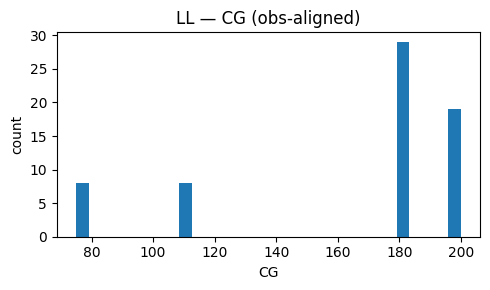

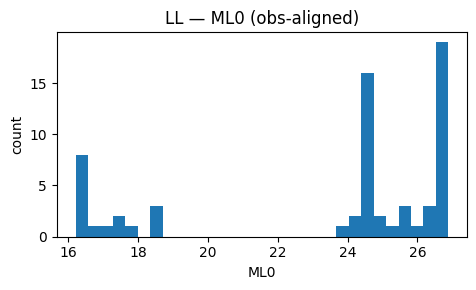

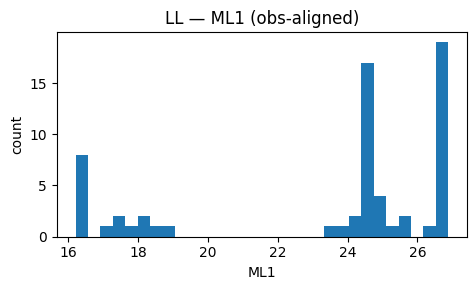


=== HL: quick histograms (observational-aligned) ===


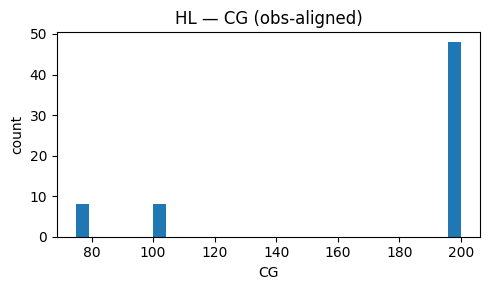

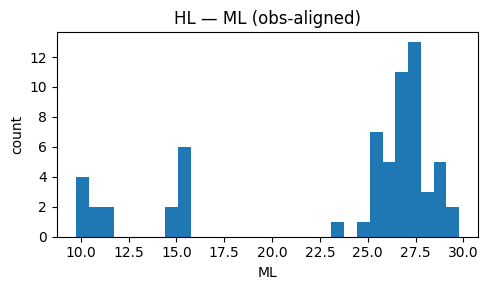


=== LL: intercepts ===
node  intercept
  CG 151.799163
 ML0   9.455870
 ML1   9.404450

=== LL: betas ===
child parent     beta
  ML0     CG 0.086994
  ML1     CG 0.085625

=== HL: intercepts ===
node  intercept
  CG 171.875000
  ML   1.888176

=== HL: betas ===
child parent     beta
   ML     CG 0.125529

[OK] Audit complete.


In [2]:
# === Battery data quick audit ===
# Run this in a fresh notebook cell.

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import joblib
import json

# If the module is in a different path, adjust sys.path accordingly
try:
    from battery_data_prep import load_and_prepare_battery
except Exception as e:
    raise RuntimeError("Could not import `load_and_prepare_battery` from battery_data_prep.py. "
                       "Make sure the file is in the working directory or adjust sys.path.") from e

CONFIG_PATH = "configs/battery_config.yaml"

# 1) Load bundles (no saving)
bundles = load_and_prepare_battery(save=False, config_path=CONFIG_PATH)
LL = bundles["LLmodel"]
HL = bundles["HLmodel"]
omega = bundles["abstraction_data"]["omega"]

LL_NODES = LL["node_order"]
HL_NODES = HL["node_order"]
ll_cg_idx = LL_NODES.index("CG")
hl_cg_idx = HL_NODES.index("CG")

print("=== Nodes ===")
print("LL nodes:", LL_NODES)
print("HL nodes:", HL_NODES)
print("\n=== ω mapping (LL→HL) ===")
for k,v in omega.items():
    lk = "None" if k is None else f"do(CG={list(k.vv().values())[0]})"
    lv = "None" if v is None else f"do(CG={list(v.vv().values())[0]})"
    print(f"{lk:>16}  →  {lv}")

# 2) Helpers
def key_str(k):
    return "None" if k is None else f"do(CG={list(k.vv().values())[0]})"

def key_str(k):
    if k is None:
        return "None"
    # intervention objects from your code have .vv()
    if hasattr(k, "vv"):
        return f"do(CG={list(k.vv().values())[0]})"
    # anything else (e.g. "U_ll_hat"/"U_hl_hat")
    return str(k)

def summarize_samples_and_noise(model, name):
    data = model["data"]
    noise = model["noise"]
    det  = model.get("deterministic", {})
    nodes = model["node_order"]
    cg_idx = nodes.index("CG")

    print(f"\n=== {name}: per-bucket sizes ===")
    rows = []
    # Only summarize *data* buckets (None + Intervention); ignore stray keys
    for iv, X in data.items():
        n = 0 if X is None else len(X)
        rows.append((key_str(iv), n))
    df_sizes = pd.DataFrame(rows, columns=["bucket", "N"]).sort_values("bucket")
    print(df_sizes.to_string(index=False))

    print(f"\n=== {name}: noise mean/std check (per bucket) ===")
    rows = []
    for iv, U in noise.items():
        # Only consider noise buckets that correspond to data buckets
        is_iv = (iv is None) or hasattr(iv, "vv")
        if not is_iv:
            continue
        if U is None or len(U) == 0:
            rows.append((key_str(iv), "—", "—", "—"))
            continue
        mu = U.mean(axis=0)
        sd = U.std(axis=0, ddof=1) if U.shape[0] > 1 else np.zeros(U.shape[1])
        cg_zero = (np.allclose(U[:, cg_idx], 0.0) if (iv is not None and hasattr(iv, "vv") and "CG" in iv.vv()) else False)
        rows.append((key_str(iv),
                     np.round(mu, 4).tolist(),
                     np.round(sd, 4).tolist(),
                     cg_zero))
    df_noise = pd.DataFrame(rows, columns=["bucket", "mean(U)", "std(U)", "CGnoiseZeroed"])
    with pd.option_context('display.max_colwidth', 120):
        print(df_noise.to_string(index=False))

    print(f"\n=== {name}: ANM reconstruction error ‖X - (D+U)‖_F / √(N·d) (per bucket) ===")
    rows = []
    for iv, X in data.items():
        if X is None or len(X) == 0:
            rows.append((key_str(iv), "—"))
            continue
        D = det.get(iv, None)
        U = noise.get(iv, None)
        if D is None or U is None or len(D) == 0 or len(U) == 0:
            rows.append((key_str(iv), "missing D or U"))
            continue
        n = min(len(X), len(D), len(U))
        Xn, Dn, Un = X[:n], D[:n], U[:n]
        err = np.linalg.norm(Xn - (Dn + Un), ord="fro") / np.sqrt(n * Xn.shape[1])
        rows.append((key_str(iv), float(np.round(err, 6))))
    df_err = pd.DataFrame(rows, columns=["bucket", "recon_rmse"])
    print(df_err.to_string(index=False))

    # (Optional) show any extra noise keys we skipped (like 'U_ll_hat')
    extra_keys = [k for k in noise.keys() if not ((k is None) or hasattr(k, "vv"))]
    if extra_keys:
        print(f"\n[info] {name}: extra noise keys not treated as buckets:", [key_str(k) for k in extra_keys])


def show_quick_hists(model, name, bins=30):
    data = model["data"]
    nodes = model["node_order"]
    cg_idx = nodes.index("CG")

    # Observational-aligned bucket (None)
    X_obs = data.get(None, None)
    if X_obs is None or len(X_obs) == 0:
        print(f"\n[WARN] {name}: No observational-aligned bucket found for quick hists.")
        return

    print(f"\n=== {name}: quick histograms (observational-aligned) ===")
    fig_list = []
    for j, node in enumerate(nodes):
        fig = plt.figure(figsize=(5, 3))
        plt.hist(X_obs[:, j], bins=bins)
        plt.title(f"{name} — {node} (obs-aligned)")
        plt.xlabel(node); plt.ylabel("count")
        plt.tight_layout()
        plt.show()
        fig_list.append(fig)

# 3) Summaries
summarize_samples_and_noise(LL, "LL")
summarize_samples_and_noise(HL, "HL")

# 4) Quick histograms on observational-aligned buckets
show_quick_hists(LL, "LL")
show_quick_hists(HL, "HL")

# 5) Extra: quick look at mechanisms (coeffs & intercepts)
def mech_table(model, name):
    coeffs = model["coeffs"]
    intercepts = model["intercepts"]
    nodes = model["node_order"]
    # Build a tidy table (child, parent, beta)
    rows = []
    for (p, ch), b in coeffs.items():
        rows.append((ch, p, b))
    df_b = pd.DataFrame(rows, columns=["child", "parent", "beta"]).sort_values(["child", "parent"])
    df_c = pd.DataFrame([{"node": k, "intercept": v} for k, v in intercepts.items()]).sort_values("node")
    print(f"\n=== {name}: intercepts ===")
    print(df_c.to_string(index=False))
    print(f"\n=== {name}: betas ===")
    print(df_b.to_string(index=False))

mech_table(LL, "LL")
mech_table(HL, "HL")

print("\n[OK] Audit complete.")

In [1]:
import os
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import joblib
import networkx as nx
from sklearn.linear_model import LinearRegression, Ridge
import scipy.stats as stats

# Optional: statsmodels (not required here). Guard to avoid SciPy conflicts.
try:
    import statsmodels.api as sm  # noqa: F401
except Exception as e:
    sm = None
    print(f"Skipping statsmodels import: {e}")

from models import LinearAddSCM, CausalBayesianNetwork, Intervention
from pgmpy.models import BayesianNetwork as BN  # noqa: F401
from pgmpy.factors.discrete import TabularCPD as cpd  # noqa: F401

seed = 23
np.random.seed(seed)
warnings.filterwarnings("ignore")

Skipping statsmodels import: cannot import name '_lazywhere' from 'scipy._lib._util' (/Users/giofelekis/opt/anaconda3/envs/erica/lib/python3.12/site-packages/scipy/_lib/_util.py)


In [1]:
import numpy as np
import pandas as pd
import joblib
import networkx as nx
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Load the prepared data
data_dir = Path("data/battery")
LLmodel = joblib.load(data_dir / "LLmodel.pkl")
HLmodel = joblib.load(data_dir / "HLmodel.pkl")
abstraction_data = joblib.load(data_dir / "abstraction_data.pkl")

print("=== DATA STRUCTURE ===")
print(f"LLmodel keys: {list(LLmodel.keys())}")
print(f"HLmodel keys: {list(HLmodel.keys())}")
print(f"abstraction_data keys: {list(abstraction_data.keys())}")

print("\n=== LL MODEL DETAILS ===")
if 'graph' in LLmodel:
    print(f"LL graph nodes: {list(LLmodel['graph'].nodes())}")
    print(f"LL graph edges: {list(LLmodel['graph'].edges())}")
else:
    print("No LL graph found")

# Check what keys exist in LLmodel
for key in LLmodel.keys():
    if hasattr(LLmodel[key], 'shape'):
        print(f"LL {key} shape: {LLmodel[key].shape}")
    elif isinstance(LLmodel[key], (list, tuple)):
        print(f"LL {key}: {len(LLmodel[key])} items")
    elif isinstance(LLmodel[key], dict):
        print(f"LL {key}: {len(LLmodel[key])} items")
    else:
        print(f"LL {key}: {type(LLmodel[key])}")

print("\n=== HL MODEL DETAILS ===")
if 'graph' in HLmodel:
    print(f"HL graph nodes: {list(HLmodel['graph'].nodes())}")
    print(f"HL graph edges: {list(HLmodel['graph'].edges())}")
else:
    print("No HL graph found")

# Check what keys exist in HLmodel
for key in HLmodel.keys():
    if hasattr(HLmodel[key], 'shape'):
        print(f"HL {key} shape: {HLmodel[key].shape}")
    elif isinstance(HLmodel[key], (list, tuple)):
        print(f"HL {key}: {len(HLmodel[key])} items")
    elif isinstance(HLmodel[key], dict):
        print(f"HL {key}: {len(HLmodel[key])} items")
    else:
        print(f"HL {key}: {type(HLmodel[key])}")

print("\n=== ABSTRACTION MAPPING ===")
for key in abstraction_data.keys():
    if hasattr(abstraction_data[key], 'shape'):
        print(f"abstraction_data {key} shape: {abstraction_data[key].shape}")
    elif isinstance(abstraction_data[key], (list, tuple)):
        print(f"abstraction_data {key}: {len(abstraction_data[key])} items")
    elif isinstance(abstraction_data[key], dict):
        print(f"abstraction_data {key}: {len(abstraction_data[key])} items")
    else:
        print(f"abstraction_data {key}: {type(abstraction_data[key])}")

=== DATA STRUCTURE ===
LLmodel keys: ['graph', 'intervention_set', 'coeffs', 'intercepts', 'data', 'noise', 'node_order', 'deterministic']
HLmodel keys: ['graph', 'intervention_set', 'coeffs', 'intercepts', 'data', 'noise', 'node_order', 'deterministic']
abstraction_data keys: ['T', 'omega']

=== LL MODEL DETAILS ===
LL graph nodes: ['CG', 'ML0', 'ML1']
LL graph edges: [('CG', 'ML0'), ('CG', 'ML1')]
LL graph: <class 'models.CausalBayesianNetwork'>
LL intervention_set: 5 items
LL coeffs: 2 items
LL intercepts: 3 items
LL data: 5 items
LL noise: 6 items
LL node_order: 3 items
LL deterministic: 5 items

=== HL MODEL DETAILS ===
HL graph nodes: ['CG', 'ML']
HL graph edges: [('CG', 'ML')]
HL graph: <class 'models.CausalBayesianNetwork'>
HL intervention_set: 4 items
HL coeffs: 1 items
HL intercepts: 2 items
HL data: 4 items
HL noise: 5 items
HL node_order: 2 items
HL deterministic: 4 items

=== ABSTRACTION MAPPING ===
abstraction_data T: <class 'NoneType'>
abstraction_data omega: 5 items


In [2]:
print("=== LL MODEL DETAILED EXPLORATION ===")
print(f"LL intervention_set: {LLmodel['intervention_set']}")
print(f"LL node_order: {LLmodel['node_order']}")

print("\nLL Coefficients:")
for node, coeffs in LLmodel['coeffs'].items():
    print(f"  {node}: {coeffs}")

print("\nLL Intercepts:")
for node, intercept in LLmodel['intercepts'].items():
    print(f"  {node}: {intercept}")

print("\nLL Data (per intervention):")
for i, data in LLmodel['data'].items():
    print(f"  Intervention {i}: shape {data.shape}")

print("\nLL Deterministic parts:")
for i, det in LLmodel['deterministic'].items():
    print(f"  Intervention {i}: shape {det.shape}")

print("\nLL Noise:")
for key, noise in LLmodel['noise'].items():
    print(f"  {key}: shape {noise.shape}")

print("\n=== HL MODEL DETAILED EXPLORATION ===")
print(f"HL intervention_set: {HLmodel['intervention_set']}")
print(f"HL node_order: {HLmodel['node_order']}")

print("\nHL Coefficients:")
for node, coeffs in HLmodel['coeffs'].items():
    print(f"  {node}: {coeffs}")

print("\nHL Intercepts:")
for node, intercept in HLmodel['intercepts'].items():
    print(f"  {node}: {intercept}")

print("\nHL Data (per intervention):")
for i, data in HLmodel['data'].items():
    print(f"  Intervention {i}: shape {data.shape}")

print("\nHL Deterministic parts:")
for i, det in HLmodel['deterministic'].items():
    print(f"  Intervention {i}: shape {det.shape}")

print("\nHL Noise:")
for key, noise in HLmodel['noise'].items():
    print(f"  {key}: shape {noise.shape}")

print("\n=== ABSTRACTION MAPPING ===")
print(f"Omega mapping: {abstraction_data['omega']}")
print(f"T matrix: {abstraction_data['T']}")

print("\n=== DATA STATISTICS ===")
# Check noise statistics
if 'U_ll_hat' in LLmodel['noise']:
    U_ll = LLmodel['noise']['U_ll_hat']
    print(f"LL noise shape: {U_ll.shape}")
    print(f"LL noise mean: {U_ll.mean(axis=0)}")
    print(f"LL noise std: {U_ll.std(axis=0)}")

if 'U_hl_hat' in HLmodel['noise']:
    U_hl = HLmodel['noise']['U_hl_hat']
    print(f"HL noise shape: {U_hl.shape}")
    print(f"HL noise mean: {U_hl.mean(axis=0)}")
    print(f"HL noise std: {U_hl.std(axis=0)}")

# Check deterministic parts
print("\nDeterministic parts statistics:")
for i, det_ll in LLmodel['deterministic'].items():
    print(f"LL Intervention {i}: mean={det_ll.mean():.4f}, std={det_ll.std():.4f}")

for i, det_hl in HLmodel['deterministic'].items():
    print(f"HL Intervention {i}: mean={det_hl.mean():.4f}, std={det_hl.std():.4f}")

=== LL MODEL DETAILED EXPLORATION ===
LL intervention_set: [None, <models.Intervention object at 0x154db3ce0>, <models.Intervention object at 0x154db3d40>, <models.Intervention object at 0x154db3dd0>, <models.Intervention object at 0x154db3e00>]
LL node_order: ['CG', 'ML0', 'ML1']

LL Coefficients:
  ('CG', 'ML0'): 0.08699382015110514
  ('CG', 'ML1'): 0.08562463682860878

LL Intercepts:
  CG: 0.0
  ML0: 9.455870193338274
  ML1: 9.404450073866705

LL Data (per intervention):
  Intervention None: shape (64, 3)
  Intervention <models.Intervention object at 0x154437680>: shape (8, 3)
  Intervention <models.Intervention object at 0x154dd00b0>: shape (8, 3)
  Intervention <models.Intervention object at 0x154dd0110>: shape (39, 3)
  Intervention <models.Intervention object at 0x154dd0170>: shape (9, 3)

LL Deterministic parts:
  Intervention None: shape (64, 3)
  Intervention <models.Intervention object at 0x154437680>: shape (8, 3)
  Intervention <models.Intervention object at 0x154dd00b0>: 

In [2]:
P_M_BASE  = Path("batteries/scms/M_WMG_bins_5_avg_2.pkl")
P_M_ABST  = Path("batteries/scms/M_LRCS_bins_5.pkl")
P_DF_BASE = Path("batteries/dfs/df_WMG_bins_5_avg_2.pkl")
P_DF_ABST = Path("batteries/dfs/df_LRCS_bins_5.pkl")

# Prefer parquet if available (version-agnostic); else fallback to joblib
P_DF_BASE_PARQ = P_DF_BASE.with_suffix(".parquet")
P_DF_ABST_PARQ = P_DF_ABST.with_suffix(".parquet")

M_base = joblib.load(P_M_BASE)
M_abst = joblib.load(P_M_ABST)

Gll = nx.DiGraph()
Gll.add_nodes_from(M_base.nodes())
Gll.add_edges_from(M_base.edges())

Ghl = nx.DiGraph()
Ghl.add_nodes_from(M_abst.nodes())
Ghl.add_edges_from(M_abst.edges())

print("LL graph nodes/edges:", list(Gll.nodes()), list(Gll.edges()))
print("HL graph nodes/edges:", list(Ghl.nodes()), list(Ghl.edges()))

# Load dataframes
if P_DF_BASE_PARQ.exists() and P_DF_ABST_PARQ.exists():
    df_base_raw = pd.read_parquet(P_DF_BASE_PARQ)
    df_abst_raw = pd.read_parquet(P_DF_ABST_PARQ)
else:
    try:
        df_base_raw = joblib.load(P_DF_BASE)
        df_abst_raw = joblib.load(P_DF_ABST)
    except Exception as e:
        raise RuntimeError(
            f"Failed to load joblib pickles (likely pandas<2 pickles on pandas 2.x). "
            f"Convert to parquet once with pandas 1.5.x, or place parquet files at: "
            f"{P_DF_BASE_PARQ} and {P_DF_ABST_PARQ}. Original error: {e}"
        )

df_base = df_base_raw[['CG', 'ML_avg0', 'ML_avg1']].copy()
df_abst = df_abst_raw[['Comma gap (µm)', 'Mass Loading (mg cm-2) ']].copy()
df_base = df_base.rename(columns={'ML_avg0':'ML0', 'ML_avg1':'ML1'})
df_abst = df_abst.rename(columns={'Comma gap (µm)':'CG', 'Mass Loading (mg cm-2) ':'ML'})

print("\nHead (LL):")
print(df_base.head())
print("\nHead (HL):")
print(df_abst.head())

LL graph nodes/edges: ['CG', 'ML0', 'ML1'] [('CG', 'ML0'), ('CG', 'ML1')]
HL graph nodes/edges: ['CG', 'ML'] [('CG', 'ML')]

Head (LL):
      CG       ML0       ML1
3  170.0  25.08116  24.92084
4  170.0  26.07010  25.85620
5  170.0  25.17962  24.82332
6  170.0  25.31420  25.29592
7  170.0  24.63494  19.52924

Head (HL):
     CG         ML
8   200  27.361725
9   200  29.772450
10  200  27.290821
11  200  27.858051
12  200  26.936303


In [3]:
LL_NODES = ['CG','ML0','ML1']
HL_NODES = ['CG','ML']

X_ll = df_base[LL_NODES].to_numpy().astype(float)  # (N_ll, 3)
X_hl = df_abst[HL_NODES].to_numpy().astype(float)  # (N_hl, 2)

print("Shapes:")
print("  X_ll:", X_ll.shape, "  (columns:", LL_NODES, ")")
print("  X_hl:", X_hl.shape, "  (columns:", HL_NODES, ")")

from sklearn.metrics import r2_score
from sklearn.linear_model import LinearRegression

def get_coefficients(data, G, use_intercept=False, verbose=True):
    """
    Fit y = b0(child) + sum_p beta_p(child) * x_p.
    If use_intercept=False, b0(child)=0 (SCM style: intercept absorbed into noise).
    Returns:
      coeffs: {(parent, child): beta}
      intercepts: {child: b0}  (0.0 if use_intercept=False or node is root)
      residuals: {node: resid vector}
      r2_train: {child: train_R2}
    """
    if not nx.is_directed_acyclic_graph(G):
        raise ValueError("Graph must be a DAG")

    nodes = list(G.nodes())
    coeffs, intercepts, residuals, r2_train = {}, {}, {}, {}

    for node in nx.topological_sort(G):
        parents = list(G.predecessors(node))
        j = nodes.index(node)
        if not parents:
            y = data[:, j]
            intercepts[node] = 0.0
            residuals[node] = y.copy()
            r2_train[node] = np.nan  # no regression for roots
            if verbose:
                print(f"Node {node}: parentless → residual only.")
            continue

        X = data[:, [nodes.index(p) for p in parents]]
        y = data[:, j]

        lr = LinearRegression(fit_intercept=use_intercept)
        lr.fit(X, y)
        yhat = lr.predict(X)
        resid = y - yhat

        for parent, beta in zip(parents, lr.coef_):
            coeffs[(parent, node)] = float(beta)
        intercepts[node] = float(lr.intercept_) if use_intercept else 0.0
        residuals[node] = resid
        r2_train[node] = float(r2_score(y, yhat))

        if verbose:
            info_betas = {p: float(b) for p, b in zip(parents, lr.coef_)}
            print(f"Node {node}: betas={info_betas} intercept={intercepts[node]:.6f} | Train R²={r2_train[node]:.4f}")

    return coeffs, intercepts, residuals, r2_train


def lan_abduction(data, G, coeffs, intercepts):
    """
    Abduce exogenous noise:
      u_child = x_child - (b0(child) + sum_p beta_{p->child} x_p)
      u_root  = x_root
    """
    nodes = list(G.nodes())
    N, d = data.shape
    U = np.zeros((N, d), dtype=float)

    for node in nx.topological_sort(G):
        j = nodes.index(node)
        parents = list(G.predecessors(node))
        if not parents:
            U[:, j] = data[:, j]
        else:
            pred = intercepts.get(node, 0.0) * np.ones(N, dtype=float)
            for p in parents:
                pred += data[:, nodes.index(p)] * coeffs[(p, node)]
            U[:, j] = data[:, j] - pred
    return U


# --- Choose intercept usage for abduction ---
USE_INTERCEPT_FOR_ABDUCTION = True  # set True to include intercept in deterministic part

print("\nFitting LL coefficients...")
ll_coeffs, ll_intercepts, ll_resid_dict, ll_r2 = get_coefficients(
    X_ll, Gll, use_intercept=USE_INTERCEPT_FOR_ABDUCTION, verbose=True
)

print("\nFitting HL coefficients...")
hl_coeffs, hl_intercepts, hl_resid_dict, hl_r2 = get_coefficients(
    X_hl, Ghl, use_intercept=USE_INTERCEPT_FOR_ABDUCTION, verbose=True
)

print("\nLL coeffs:", ll_coeffs)
print("LL intercepts:", ll_intercepts)
print("HL coeffs:", hl_coeffs)
print("HL intercepts:", hl_intercepts)

# --- Abduce exogenous noise ---
U_ll = lan_abduction(X_ll, Gll, ll_coeffs, ll_intercepts)
U_hl = lan_abduction(X_hl, Ghl, hl_coeffs, hl_intercepts)

print("\nExogenous sample matrices:")
print("  U_ll shape:", U_ll.shape, " (columns:", LL_NODES, ")")
print("  U_hl shape:", U_hl.shape, " (columns:", HL_NODES, ")")

# --- Reconstruction check: x ≈ b0 + A x + u
def _recon_error(data, G, coeffs, intercepts):
    nodes = list(G.nodes())
    N, d = data.shape
    err = {}
    for node in nodes:
        j = nodes.index(node)
        parents = list(G.predecessors(node))
        if not parents:
            recon = data[:, j]
        else:
            pred = intercepts.get(node, 0.0) * np.ones(N, dtype=float)
            for p in parents:
                pred += data[:, nodes.index(p)] * coeffs[(p, node)]
            recon = pred + (data[:, j] - pred)
        err[node] = float(np.max(np.abs(recon - data[:, j])))
    return err

print("\nMax reconstruction |error| per node (should be ~1e-12 to 1e-15):")
print("  LL:", _recon_error(X_ll, Gll, ll_coeffs, ll_intercepts))
print("  HL:", _recon_error(X_hl, Ghl, hl_coeffs, hl_intercepts))

# --- Report Train R² neatly ---
def _report_r2(title, r2_map, nodes):
    print(f"\n{title} Train R²:")
    for n in nodes:
        if n in r2_map and not np.isnan(r2_map[n]):
            print(f"  {n}: {r2_map[n]:.4f}")

_report_r2("LL (CG→ML0, ML1)", ll_r2, ['ML0','ML1'])
_report_r2("HL (CG→ML)", hl_r2, ['ML'])

# --- Stash in a dict for downstream cells ---
EXOGENOUS_SAMPLES = {
    'X_ll': X_ll, 'X_hl': X_hl,
    'U_ll': U_ll, 'U_hl': U_hl,
    'll_coeffs': ll_coeffs, 'hl_coeffs': hl_coeffs,
    'll_intercepts': ll_intercepts, 'hl_intercepts': hl_intercepts,
    'll_r2_train': ll_r2, 'hl_r2_train': hl_r2,
}

Shapes:
  X_ll: (239, 3)   (columns: ['CG', 'ML0', 'ML1'] )
  X_hl: (64, 2)   (columns: ['CG', 'ML'] )

Fitting LL coefficients...
Node CG: parentless → residual only.
Node ML0: betas={'CG': 0.08699382015110513} intercept=9.455870 | Train R²=0.9291
Node ML1: betas={'CG': 0.08562463682860881} intercept=9.404450 | Train R²=0.7166

Fitting HL coefficients...
Node CG: parentless → residual only.
Node ML: betas={'CG': 0.1255290700068597} intercept=1.888176 | Train R²=0.9645

LL coeffs: {('CG', 'ML0'): 0.08699382015110513, ('CG', 'ML1'): 0.08562463682860881}
LL intercepts: {'CG': 0.0, 'ML0': 9.455870193338276, 'ML1': 9.404450073866702}
HL coeffs: {('CG', 'ML'): 0.1255290700068597}
HL intercepts: {'CG': 0.0, 'ML': 1.888175925343731}

Exogenous sample matrices:
  U_ll shape: (239, 3)  (columns: ['CG', 'ML0', 'ML1'] )
  U_hl shape: (64, 2)  (columns: ['CG', 'ML'] )

Max reconstruction |error| per node (should be ~1e-12 to 1e-15):
  LL: {'CG': 0.0, 'ML0': 0.0, 'ML1': 8.881784197001252e-16}
  HL:

In [4]:
import scipy.stats as stats

# --- Shapiro-Wilk Test on CORRECTED Residuals ---
print("--- Shapiro-Wilk Test on CORRECTED Residuals (from intercept model) ---")

print("Low-Level (LL) Residuals:")
for node, resid in ll_resid_dict.items():
    if len(resid) >= 10:
        # Test on up to 5000 samples for performance
        stat, pval = stats.shapiro(resid[:5000]) 
    else:
        stat, pval = np.nan, np.nan
    print(f"  - Node {node}: p-value = {pval:.4f}")
    if pval < 0.05:
        print("    -> CONCLUSION: Residuals are NOT Gaussian.")
    else:
        print("    -> CONCLUSION: Residuals are consistent with Gaussian.")

print("\nHigh-Level (HL) Residuals:")
for node, resid in hl_resid_dict.items():
    if len(resid) >= 10:
        stat, pval = stats.shapiro(resid[:5000])
    else:
        stat, pval = np.nan, np.nan
    print(f"  - Node {node}: p-value = {pval:.4f}")
    if pval < 0.05:
        print("    -> CONCLUSION: Residuals are NOT Gaussian.")
    else:
        print("    -> CONCLUSION: Residuals are consistent with Gaussian.")

--- Shapiro-Wilk Test on CORRECTED Residuals (from intercept model) ---
Low-Level (LL) Residuals:
  - Node CG: p-value = 0.0000
    -> CONCLUSION: Residuals are NOT Gaussian.
  - Node ML0: p-value = 0.0000
    -> CONCLUSION: Residuals are NOT Gaussian.
  - Node ML1: p-value = 0.0000
    -> CONCLUSION: Residuals are NOT Gaussian.

High-Level (HL) Residuals:
  - Node CG: p-value = 0.0000
    -> CONCLUSION: Residuals are NOT Gaussian.
  - Node ML: p-value = 0.6533
    -> CONCLUSION: Residuals are consistent with Gaussian.


In [5]:
rng = np.random.default_rng(seed)  # reproducible sampling

LL_NODES = ['CG','ML0','ML1']
HL_NODES = ['CG','ML']
X_ll_full = EXOGENOUS_SAMPLES['X_ll']   # (N_ll, 3)
X_hl_full = EXOGENOUS_SAMPLES['X_hl']   # (N_hl, 2)
U_ll_full = EXOGENOUS_SAMPLES['U_ll']   # (N_ll, 3)
U_hl_full = EXOGENOUS_SAMPLES['U_hl']   # (N_hl, 2)

df_ll_obs = pd.DataFrame(X_ll_full, columns=LL_NODES)
df_hl_obs = pd.DataFrame(X_hl_full, columns=HL_NODES)

print("Raw sizes BEFORE alignment:")
print(f"  LL: X_ll {X_ll_full.shape}  U_ll {U_ll_full.shape}")
print(f"  HL: X_hl {X_hl_full.shape}  U_hl {U_hl_full.shape}")

omega_cg_map = {
    75.0: 75.0,
    110.0: 100.0,
    180.0: 200.0,
    200.0: 200.0,
}

hl_to_ll = {}
for cg_ll, cg_hl in omega_cg_map.items():
    hl_to_ll.setdefault(cg_hl, []).append(cg_ll)

ll_counts = df_ll_obs['CG'].value_counts().sort_index()
hl_counts = df_hl_obs['CG'].value_counts().sort_index()

print("\nCounts per LL CG:")
for cg, c in ll_counts.items():
    print(f"  LL CG={cg:.0f}: {c}")
print("\nCounts per HL CG:")
for cg, c in hl_counts.items():
    print(f"  HL CG={cg:.0f}: {c}")

print("\nHL→{LLs} buckets:")
for hcg, ll_list in hl_to_ll.items():
    print(f"  HL CG={hcg:.0f}  <=  LL CGs {ll_list}")


def take_indices_group(df, cg_value, k, rng):
    idx = df.index[df['CG'] == cg_value].to_numpy()
    if len(idx) < k:
        raise ValueError(f"Not enough rows for CG={cg_value}: need {k}, have {len(idx)}")
    rng.shuffle(idx)
    return idx[:k]

Xll_chunks, Ull_chunks = [], []
Xhl_chunks, Uhl_chunks = [], []

print("\nAllocation per HL bucket:")
for cg_hl, ll_cgs in hl_to_ll.items():
    # rows available in HL for this bucket
    hl_idx = df_hl_obs.index[df_hl_obs['CG'] == cg_hl].to_numpy()
    n_hl = len(hl_idx)
    if n_hl == 0:
        continue

    # total LL pool available (sum over mapped LL cgs)
    ll_avail = {cg_ll: int((df_ll_obs['CG'] == cg_ll).sum()) for cg_ll in ll_cgs}
    total_ll = sum(ll_avail.values())
    take_total = n_hl

    print(f"  HL CG={cg_hl:.0f}: n_hl={n_hl}, total_ll={total_ll}, take_total={take_total}")

    # proportional allocation with rounding
    alloc = {}
    if total_ll == 0:
        raise ValueError(f"No LL rows available for HL CG={cg_hl}")
    remaining = take_total
    for j, cg_ll in enumerate(ll_cgs):
        if j < len(ll_cgs) - 1:
            share = int(round(take_total * ll_avail[cg_ll] / total_ll))
            share = min(share, ll_avail[cg_ll])
            alloc[cg_ll] = share
            remaining -= share
        else:
            alloc[cg_ll] = min(remaining, ll_avail[cg_ll])

    # If rounding undershot, top-up earliest groups with room
    if sum(alloc.values()) < take_total:
        deficit = take_total - sum(alloc.values())
        for cg_ll in ll_cgs:
            room = ll_avail[cg_ll] - alloc[cg_ll]
            add = min(room, deficit)
            alloc[cg_ll] += add
            deficit -= add
            if deficit == 0:
                break

    # Take LL indices per cg_ll according to alloc
    ll_indices_sel = []
    for cg_ll, k in alloc.items():
        print(f"    LL CG={cg_ll:.0f}: have={ll_avail[cg_ll]}, take={k}")
        if k > 0:
            ll_indices_sel.append(take_indices_group(df_ll_obs, cg_ll, k, rng))
    if len(ll_indices_sel) > 0:
        ll_indices_sel = np.concatenate(ll_indices_sel)
    else:
        ll_indices_sel = np.array([], dtype=int)

    # Shuffle both sets *independently* within the bucket, then pair
    hl_idx_shuf = hl_idx.copy()
    rng.shuffle(hl_idx_shuf)
    rng.shuffle(ll_indices_sel)

    assert len(hl_idx_shuf) == len(ll_indices_sel), "Bucket sizes must match."

    # Append chunks (paired by order within this bucket)
    Xll_chunks.append(X_ll_full[ll_indices_sel])
    Ull_chunks.append(U_ll_full[ll_indices_sel])
    Xhl_chunks.append(X_hl_full[hl_idx_shuf])
    Uhl_chunks.append(U_hl_full[hl_idx_shuf])


if len(Xll_chunks) == 0:
    raise RuntimeError("No aligned chunks were created. Check ω mapping and counts.")

X_ll_aligned = np.vstack(Xll_chunks)
U_ll_aligned = np.vstack(Ull_chunks)
X_hl_aligned = np.vstack(Xhl_chunks)
U_hl_aligned = np.vstack(Uhl_chunks)

print("\nAFTER alignment (observational 'None'):")
print("  LL aligned:", X_ll_aligned.shape, U_ll_aligned.shape)
print("  HL aligned:", X_hl_aligned.shape, U_hl_aligned.shape)

# Stash aligned in a dict for the next cell
ALIGNED = {
    'X_ll': X_ll_aligned,
    'U_ll': U_ll_aligned,
    'X_hl': X_hl_aligned,
    'U_hl': U_hl_aligned,
    'omega_cg_map': omega_cg_map,
}
print("\n✓ Cell 4 complete. Aligned matrices are ready.")


Raw sizes BEFORE alignment:
  LL: X_ll (239, 3)  U_ll (239, 3)
  HL: X_hl (64, 2)  U_hl (64, 2)

Counts per LL CG:
  LL CG=75: 20
  LL CG=110: 10
  LL CG=150: 142
  LL CG=170: 8
  LL CG=180: 39
  LL CG=200: 20

Counts per HL CG:
  HL CG=75: 8
  HL CG=100: 8
  HL CG=200: 48

HL→{LLs} buckets:
  HL CG=75  <=  LL CGs [75.0]
  HL CG=100  <=  LL CGs [110.0]
  HL CG=200  <=  LL CGs [180.0, 200.0]

Allocation per HL bucket:
  HL CG=75: n_hl=8, total_ll=20, take_total=8
    LL CG=75: have=20, take=8
  HL CG=100: n_hl=8, total_ll=10, take_total=8
    LL CG=110: have=10, take=8
  HL CG=200: n_hl=48, total_ll=59, take_total=48
    LL CG=180: have=39, take=32
    LL CG=200: have=20, take=16

AFTER alignment (observational 'None'):
  LL aligned: (64, 3) (64, 3)
  HL aligned: (64, 2) (64, 2)

✓ Cell 4 complete. Aligned matrices are ready.


In [6]:
X_ll_aligned = ALIGNED['X_ll']   # (N, 3) columns: ['CG','ML0','ML1']
U_ll_aligned = ALIGNED['U_ll']   # (N, 3)
X_hl_aligned = ALIGNED['X_hl']   # (N, 2) columns: ['CG','ML']
U_hl_aligned = ALIGNED['U_hl']   # (N, 2)
omega_cg_map  = ALIGNED['omega_cg_map']

ll_coeffs = EXOGENOUS_SAMPLES['ll_coeffs']  # {('CG','ML0'): β, ('CG','ML1'): β}
hl_coeffs = EXOGENOUS_SAMPLES['hl_coeffs']  # {('CG','ML'): β}

# Node orders (fixed)
LL_NODES = ['CG','ML0','ML1']
HL_NODES = ['CG','ML']

# --- Build SCM graphs (CausalBayesianNetwork expects edge list) ---
ll_causal_graph = CausalBayesianNetwork(list(ll_coeffs.keys()))
hl_causal_graph = CausalBayesianNetwork(list(hl_coeffs.keys()))

# --- Helper: select rows by CG value (first col = CG) ---
def _select_by_cg(mat, cg_value, tol=1e-9):
    mask = np.isclose(mat[:, 0], float(cg_value), atol=tol)
    return mat[mask]

# --------------------------
# 1) Per-intervention DATA dicts
#    (observational + per-CG subsets)
# --------------------------
Dll_samples = {}
Dhl_samples = {}

# Observational 'None'
Dll_samples[None] = X_ll_aligned
Dhl_samples[None] = X_hl_aligned

# LL interventions (available CGs in alignment): 75, 110, 180, 200
for cg_ll in [75.0, 110.0, 180.0, 200.0]:
    Dll_samples[Intervention({'CG': cg_ll})] = _select_by_cg(X_ll_aligned, cg_ll)

# HL interventions (available CGs in alignment): 75, 100, 200
for cg_hl in [75.0, 100.0, 200.0]:
    Dhl_samples[Intervention({'CG': cg_hl})] = _select_by_cg(X_hl_aligned, cg_hl)

print("LL per-intervention counts (aligned):")
for k, v in Dll_samples.items():
    lab = "None" if k is None else k.vv()
    print(f"  {lab}: {v.shape}")

print("HL per-intervention counts (aligned):")
for k, v in Dhl_samples.items():
    lab = "None" if k is None else k.vv()
    print(f"  {lab}: {v.shape}")

# --------------------------
# 2) Noise dicts — you asked to store ONLY samples
#    Keep observational exogenous under key None
# --------------------------
Dll_noise = {None: U_ll_aligned}
Dhl_noise = {None: U_hl_aligned}

print("\nNoise (observational only):")
print("  U_ll[None]:", Dll_noise[None].shape)
print("  U_hl[None]:", Dhl_noise[None].shape)

# --------------------------
# 3) Intervention sets & SCM instances
# --------------------------
Ill_relevant = [None, Intervention({'CG': 75.0}), Intervention({'CG': 110.0}),
                Intervention({'CG': 180.0}), Intervention({'CG': 200.0})]
Ihl_relevant = [None, Intervention({'CG': 75.0}), Intervention({'CG': 100.0}),
                Intervention({'CG': 200.0})]

LLmodels = {iota: LinearAddSCM(ll_causal_graph, ll_coeffs, iota) for iota in Ill_relevant}
HLmodels = {eta:  LinearAddSCM(hl_causal_graph, hl_coeffs, eta)  for eta in Ihl_relevant}


LLmodel = {
    'graph': ll_causal_graph,
    'intervention_set': Ill_relevant,
    'coeffs': ll_coeffs,                
    'data': Dll_samples,                 
    'noise': Dll_noise,                  
    'scm_instances': LLmodels,
    'node_order': LL_NODES,
}

HLmodel = {
    'graph': hl_causal_graph,
    'intervention_set': Ihl_relevant,
    'coeffs': hl_coeffs,
    'data': Dhl_samples,
    'noise': Dhl_noise,
    'scm_instances': HLmodels,
    'node_order': HL_NODES,
}


omega = {
    None: None,
    Intervention({'CG': 75.0}):  Intervention({'CG': 75.0}),
    Intervention({'CG': 110.0}): Intervention({'CG': 100.0}),
    Intervention({'CG': 180.0}): Intervention({'CG': 200.0}),
    Intervention({'CG': 200.0}): Intervention({'CG': 200.0}),
}

abstraction_data = {
    'T': None,     
    'omega': omega,
}

# experiment = "battery"
# outdir = f"data/{experiment}"
# os.makedirs(outdir, exist_ok=True)

# joblib.dump(LLmodel, f"{outdir}/LLmodel.pkl")
# joblib.dump(HLmodel, f"{outdir}/HLmodel.pkl")
# joblib.dump(abstraction_data, f"{outdir}/abstraction_data.pkl")


LL per-intervention counts (aligned):
  None: (64, 3)
  {'CG': 75.0}: (8, 3)
  {'CG': 110.0}: (8, 3)
  {'CG': 180.0}: (32, 3)
  {'CG': 200.0}: (16, 3)
HL per-intervention counts (aligned):
  None: (64, 2)
  {'CG': 75.0}: (8, 2)
  {'CG': 100.0}: (8, 2)
  {'CG': 200.0}: (48, 2)

Noise (observational only):
  U_ll[None]: (64, 3)
  U_hl[None]: (64, 2)


In [ ]:


# Load previously saved models
_ll_path = "data/battery/LLmodel.pkl"
_hl_path = "data/battery/HLmodel.pkl"
LLmodel = joblib.load(_ll_path)
HLmodel = joblib.load(_hl_path)

# Prefer intercepts/coeffs from EXOGENOUS_SAMPLES if present; else from model
ll_coeffs = EXOGENOUS_SAMPLES.get('ll_coeffs', LLmodel.get('coeffs'))
hl_coeffs = EXOGENOUS_SAMPLES.get('hl_coeffs', HLmodel.get('coeffs'))
ll_intercepts = EXOGENOUS_SAMPLES.get('ll_intercepts', LLmodel.get('intercepts', {}))
hl_intercepts = EXOGENOUS_SAMPLES.get('hl_intercepts', HLmodel.get('intercepts', {}))

# Helper: parents map from graph
def _parents_map(graph, node_order):
    p = {n: [] for n in node_order}
    for u, v in graph.edges():
        p[v].append(u)
    return p

# Compute D per intervention using stored coeffs/intercepts if available; fall back to refitting if missing

def _compute_D_per_iv(model_dict, coeffs, intercepts):
    data_by_iv = model_dict['data']
    node_order = model_dict['node_order']
    parents = _parents_map(model_dict['graph'], node_order)
    D_dict = {}
    for iv, X in data_by_iv.items():
        if X is None:
            continue
        X = np.asarray(X)
        N, d = X.shape
        D = np.zeros((N, d), dtype=float)
        for j, child in enumerate(node_order):
            pa = parents.get(child, [])
            if len(pa) == 0:
                D[:, j] = 0.0
                continue
            X_pa = X[:, [node_order.index(p) for p in pa]]
            # If we have stored intercept/coeffs, use them; else refit
            if (child in intercepts) and all(((p, child) in coeffs) for p in pa):
                b0 = float(intercepts[child])
                betas = np.array([coeffs[(p, child)] for p in pa], dtype=float)
                D[:, j] = b0 + X_pa @ betas
            else:
                lr = LinearRegression(fit_intercept=True).fit(X_pa, X[:, j])
                D[:, j] = lr.intercept_ + X_pa @ lr.coef_.astype(float)
        D_dict[iv] = D
    return D_dict

# Compute and attach
det_ll_dict = _compute_D_per_iv(LLmodel, ll_coeffs, ll_intercepts)
det_hl_dict = _compute_D_per_iv(HLmodel, hl_coeffs, hl_intercepts)

LLmodel['intercepts'] = ll_intercepts
HLmodel['intercepts'] = hl_intercepts
LLmodel['deterministic'] = det_ll_dict
HLmodel['deterministic'] = det_hl_dict


✓ Deterministic parts computed and saved into LLmodel/HLmodel.
